# 카메라 스티커앱 만들기

## 카메라앱 기능 구현하기

In [1]:
!mkdir -p ~/work/camera_sticker/models
!mkdir -p ~/work/camera_sticker/images

In [2]:
# 1. AI 사진(face1.jpeg)을 새 폴더로 옮기면서 이름은 'my_face.jpg'로 바꾸기
!mv ~/work/AIFFEL_quest_eng/Computer_Vision/CV01/face1.jpeg ~/work/camera_sticker/images/my_face.jpg

# 2. 고양이 수염(cat-whiskers.png)을 새 폴더로 옮기면서 이름은 'whiskers.png'로 바꾸기
!mv ~/work/AIFFEL_quest_eng/Computer_Vision/CV01/cat-whiskers.png ~/work/camera_sticker/images/whiskers.png

mv: cannot stat '/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/face1.jpeg': No such file or directory
mv: cannot stat '/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/cat-whiskers.png': No such file or directory


In [16]:
!pip install cmake
!pip install opencv-python
!conda install -y dlib

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [17]:
# 필요한 패키지 import 하기
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리

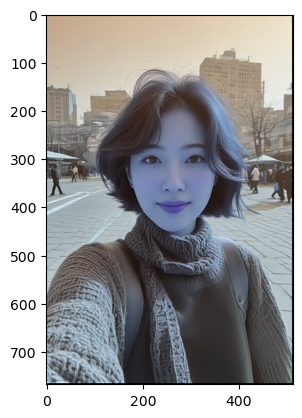

In [80]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/camera_sticker/images/my_face.jpg') # 본인 이미지가 있는 경로를 가지고 온다.
img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
plt.imshow(img_bgr) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)
plt.show() # 이미지를 출력해준다. (실제 출력)

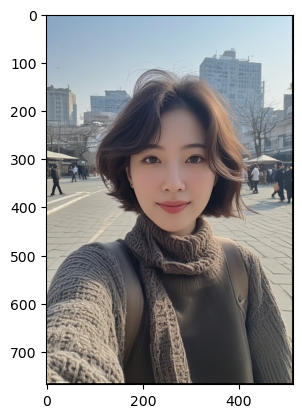

In [62]:
# plt.imshow 이전에 RGB 이미지로 바꾸는 것을 잊지마세요.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 
# (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

### 얼굴 탐지

In [20]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환

In [21]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)

rectangles[[(180, 263) (366, 449)]]


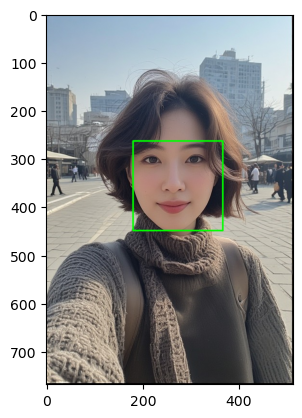

In [78]:
# 찾은 얼굴 영역 박스 리스트
# 여러 얼굴이 있을 수 있습니다
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) 
    # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

### 얼굴 랜드마크

In [23]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models
!cd ~/work/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

--2026-04-20 06:15:14--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-20 06:15:15--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  16.5MB/s    in 4.1s    

2026-04-20 06:15:19 (15.0 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file ./models/shape_predictor_68_face_landmarks.dat already exists.


In [24]:
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
    # 저장한 landmark 모델의 주소를 model_path 변수에 저장
landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄

In [25]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


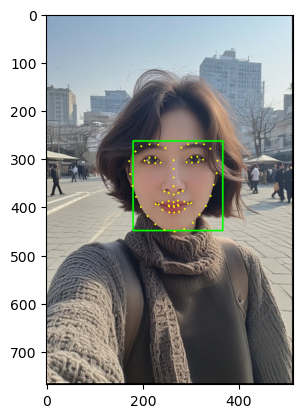

In [26]:
# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    # RGB 이미지로 전환
plt.imshow(img_show_rgb)
    # 이미지를 준비
plt.show()
    # 이미지를 출력

In [58]:
# zip() : 두 그룹의 데이터를 서로 엮어주는 파이썬의 내장 함수
# dlib_rects와 list_landmarks 데이터를 엮어 주었음
# dlib_rects : 얼굴 영역을 저장하고 있는 값
# → rectangles[[(345, 98) (531, 284)]]
# list_landmarks : 68개의 랜드마크 값 저장(이목구비 위치(x,y))
# → [[(368, 153), (368, 174), (371, 195), (376, 215), (382, 235), (391, 252), (404, 266), (420, 277), (441, 279), (461, 276), (480, 266), (495, 252), (508, 235), (516, 216), (520, 195), (523, 173), (524, 151), (377, 131), (386, 119), (399, 116), (413, 118), (425, 124), (454, 121), (466, 114), (481, 112), (494, 114), (503, 127), (439, 143), (438, 156), (438, 169), (437, 182), (423, 197), (431, 199), (438, 200), (446, 199), (454, 197), (391, 147), (399, 142), (409, 143), (416, 149), (408, 150), (399, 150), (464, 147), (472, 141), (482, 141), (489, 145), (482, 149), (473, 149), (411, 227), (421, 222), (432, 218), (439, 220), (446, 218), (458, 222), (471, 227), (458, 234), (446, 238), (438, 238), (431, 238), (420, 235), (415, 227), (432, 227), (439, 228), (447, 227), (466, 227), (446, 228), (438, 229), (431, 228)]]

for dlib_rect, landmark in zip(dlib_rects, list_landmarks): 
    # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    print (landmark[30]) # 코의 index는 30 입니다
    x = landmark[30][0] # 이미지에서 코 부위의 x값
    y = landmark[30][1] - dlib_rect.height()//2 
    # 이미지에서 코 부위의 y값 - 얼굴 영역의 세로를 차지하는 픽셀의 수//2 → (437, 182-(186+1//2))
    w = h = dlib_rect.width() 
    # 얼굴 영역의 가로를 차지하는 픽셀의 수 
    # (531-345+1) → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(264, 357)
(x,y) : (264,264)
(w,h) : (187,187)


In [59]:
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/cat-whiskers.png')

img_sticker = cv2.imread(sticker_path)

print (img_sticker.shape) 

(512, 512, 3)


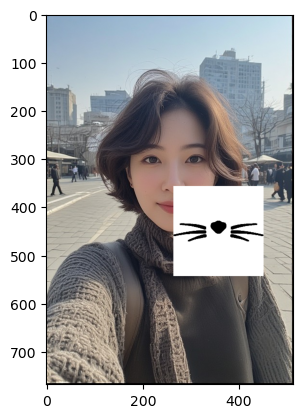

In [81]:
# 기준점(코끝) 좌표 찾기
nose_x = list_landmarks[0][30][0]
nose_y = list_landmarks[0][30][1]

w = dlib_rect.width()
h = dlib_rect.height()
img_sticker = cv2.resize(img_sticker, (w, h))

# 원본 사진 복사본 만들기
img_bgr_test1 = img_bgr.copy()

# 스티커 붙이기
# 사진에서 스티커가 들어갈 영역을 정하고, 거기에 스티커 이미지를 덮어씌웁니다.
img_bgr_test1[nose_y:nose_y+img_sticker.shape[0], nose_x:nose_x+img_sticker.shape[1]] = img_sticker

# 결과 출력
plt.imshow(cv2.cvtColor(img_bgr_test1, cv2.COLOR_BGR2RGB))
plt.show()

위치 보정하고 배경 투명하게 만들기


In [72]:
temp_img = img_bgr.copy()
# 코 중심에서 스티커 크기의 절반씩 빼기
refined_x = nose_x - w // 2
refined_y = nose_y - h // 2

# 투명도 np.where 사용
sticker_area = img_bgr[refined_y : refined_y + h, refined_x : refined_x + w]


In [73]:
print (f'(x,y) : ({refined_x},{refined_y})') 

(x,y) : (171,264)


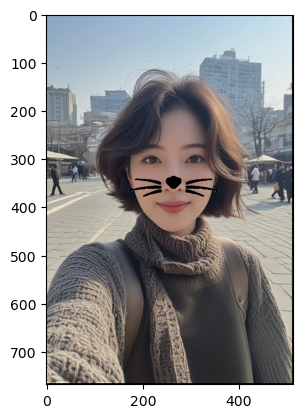

In [82]:
# 하얀색(255) 배경은 원래 사진을 쓰고, 수염은 스티커 이미지 쓰기
img_bgr[refined_y : refined_y + h, refined_x : refined_x + w] = \
    np.where(img_sticker == 255, sticker_area, img_sticker).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

### 다른 각도 사진

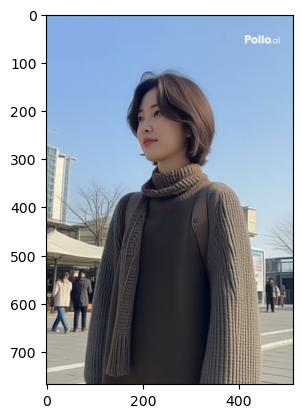

In [86]:
image_path = os.path.join(home_dir, 'work/camera_sticker/images/face3.png')
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) 
plt.show() 

얼굴을 찾아보자

rectangles[[(163, 175) (270, 283)]]


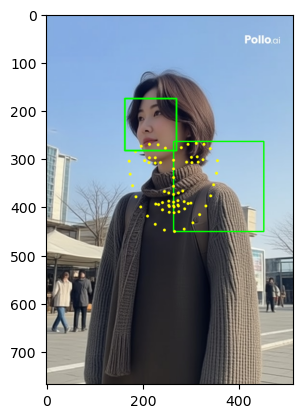

In [90]:

detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)

# 찾은 얼굴 영역 박스 리스트
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) 
    # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

기존 방식으로 해보니 얼굴 인식이 제대로 되지 않는다. 바운딩 박스는 되지만 눈코입 인식이 이상한곳으로 되어있음

In [96]:
# 다시 원본 사진 불러오기
image_path = os.path.expanduser('~/work/camera_sticker/images/face3.png')
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

dlib_rects = detector_hog(img_rgb, 2) # 파라미터 2로 올려서 분석하기
print(f"찾은 얼굴 개수: {len(dlib_rects)}")


찾은 얼굴 개수: 1


얼굴 랜드마크 다시 찍어야함

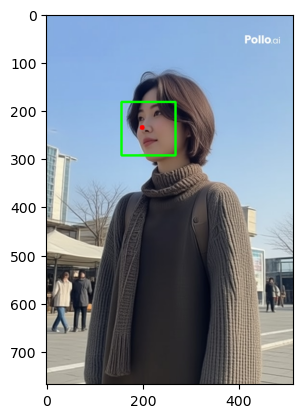

In [117]:
# 만약(if) 찾은 얼굴의 개수(len)가 0보다 크다면 (얼굴을 하나라도 찾았다면)
if len(dlib_rects) > 0:
    shape = landmark_predictor(img_rgb, dlib_rects[0])
    list_points = list(map(lambda p: (p.x, p.y), shape.parts()))
    
    # 복사본 만들어서
    img_show = img_bgr.copy()
    # 얼굴 상자 그리기
    dlib_rect = dlib_rects[0]
    cv2.rectangle(img_show, (dlib_rect.left(), dlib_rect.top()), 
                  (dlib_rect.right(), dlib_rect.bottom()), (0, 255, 0), 3)
    
    # 코끝(30번)만 빨간색으로 그리기
    cv2.circle(img_show, list_points[30], 5, (0, 0, 255), -1)
    
    plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    plt.show()

수염을 붙여보자. 그런데 각도가 정면이 아니니 변경된 각도로 붙여보자

눈의 위치를 보고 몇 도 정도 바꿔야 할지 구해보고 거기에 맞춰서 수염을 붙여보자

In [118]:
import math # 각도 구할 때 필요함

# 두 눈의 위치로 얼굴이 기운 각도 계산하기
# 36번(왼쪽 눈 끝)과 45번(오른쪽 눈 끝) 점을 사용
left_eye = list_points[36]
right_eye = list_points[45]

# 가로 차이(dx)와 세로 차이(dy)를 구합니다.
dx = right_eye[0] - left_eye[0]
dy = right_eye[1] - left_eye[1]

# 각도를 구하고 Degree로 바꾸기
angle = math.degrees(math.atan2(dy, dx))
print(f"{angle:.1f}도 만큼 기움")

# 스티커 이미지를 각도만큼 돌리기
(h_s, w_s) = img_sticker.shape[:2] # 스티커 원래 크기
center = (w_s // 2, h_s // 2)    # 스티커의 정중앙을 회전축으로 잡기

# 회전 시킬 '명령서(행렬)'를 만듭니다. (중심점, 각도, 크기배율)
M = cv2.getRotationMatrix2D(center, -angle, 1.0)

# 실제로 종이를 돌립니다! 빈 공간은 하얀색(255)으로 채워요.
rotated_sticker = cv2.warpAffine(img_sticker, M, (w_s, h_s), borderValue=(255, 255, 255))

-23.1도 만큼 기움


각도도 구했으니, 수염 붙여보자

In [142]:
# 내 얼굴 크기에 맞춰 스티커 사이즈 조절하기
w = dlib_rect.width()
h = int(dlib_rect.height() * 0.7) # 원하는 비율로 곱하기(픽셀은 소수점이 될 수 없으니 정수 int로 바꿔주는게 필요함)
rotated_sticker = cv2.resize(rotated_sticker, (w, h))

# 스티커가 붙을 '시작점' 계산하기
# 코끝(30번 점)에서 스티커 너비의 절반만큼 왼쪽, 높이의 절반만큼 위로 이동
refined_x = list_points[30][0] - w // 2
refined_y = list_points[30][1] - h // 2

# 사진 밖으로 나가는지 체크
if refined_x < 0: refined_x = 0
if refined_y < 0: refined_y = 0


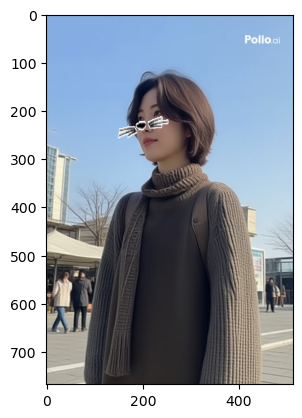

In [144]:
# 원본 사진 복사본 만들기
temp_img = img_bgr.copy()

# 스티커가 들어갈 '네모난 영역'만 따로 떼어보기
sticker_area = temp_img[refined_y : refined_y + h, refined_x : refined_x + w]

# np.where로 하얀 배경(255)은 원래 사진을 보여주고, 아니면 수염을 그리기
temp_img[refined_y : refined_y + h, refined_x : refined_x + w] = \
    np.where(rotated_sticker == 255, sticker_area, rotated_sticker).astype(np.uint8)

plt.imshow(cv2.cvtColor(temp_img, cv2.COLOR_BGR2RGB))
plt.show()